# Calibrating the LIX long-word threshold for Hungarian**The question.** LIX is `A/B + 100·C/A`, where *C* counts words longer than a threshold.Björnsson fixed that threshold at six letters, fitted to Swedish, and every Pythonimplementation hardcodes it. Hungarian is agglutinative — does 6 still pick out ameaningful set of words, and if not, what does?**The method.** Equipercentile matching. Rather than keeping the literal 6, keep what thesecond term *means* — the longest X% of running words — by finding the Hungarian thresholdwhose long-word share matches the share `>6` selects in a Germanic reference.**Four things decide whether this is right**, all of which fail silently:1. Token-weighted, never type-weighted — a frequency list is a list of *types*, and rare   types are long.2. The 4% stratum, not the full-corpus column, which carries the crawl's junk.3. Strip the trailing `*` capitalisation marker *before* filtering — it marks short   function words, and discarding them biases the mean length upward.4. Decode as ISO-8859-2 — UTF-8 silently corrupts `ő` and `ű`.This notebook **reads the artifacts**; it does not recompute them. Run the scripts first:```bashuv run python experiments/lix_calibration/scripts/download_data.py --with-corpus-partuv run python experiments/lix_calibration/scripts/run.pyuv run python experiments/lix_calibration/scripts/validate_b.py```

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

BASE = Path(".")  # run from experiments/lix_calibration/
record = json.loads((BASE / "results" / "lix_calibration.json").read_text())

CURVES = record["curves"]
REC = record["recommendation"]
print(f"saphes {record['saphes_version']} · generated {record['generated']}")
print(f"recommended Hungarian threshold: {REC['long_word_threshold']}")

saphes 0.1.0 · generated 2026-07-29T17:08:25+00:00
recommended Hungarian threshold: 8


## The paletteTwo hues, because there are two *entities*: Hungarian and Swedish. The several Hungariancurves are the same language measured differently, so they share a hue and separate by linestyle — colour follows the entity, not the row of the table.Validated with the data-viz palette checker: worst-pair CVD ΔE 24.7 (target ≥ 8),normal-vision ΔE 33.6 (floor 15), both above 3:1 against the surface.

In [2]:
HU = "#2a78d6"       # categorical slot 1, blue
SV = "#eb6834"       # categorical slot 2, orange
SURFACE = "#fcfcfb"
INK = "#0b0b0b"
INK_2 = "#52514e"
MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_2,
    "axes.titlecolor": INK,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "text.color": INK,
    "font.size": 10,
    "lines.linewidth": 2,
    "figure.dpi": 110,
})


def shares(label, upto=14):
    """Cumulative long-word shares for one curve, as (thresholds, shares)."""
    table = CURVES[label]["shares"]
    ts = [t for t in range(1, upto + 1) if str(t) in table]
    return ts, [table[str(t)] for t in ts]

## 1. The headlineRead across the threshold-6 gridline: Hungarian sits far above Swedish. Read *down* fromSwedish's share to where it crosses the Hungarian curve, and that is the matched threshold.

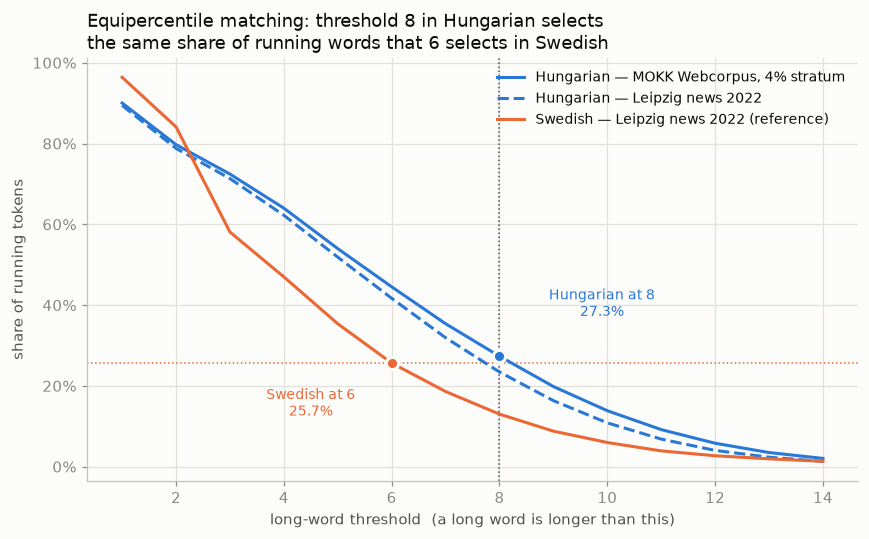

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

ref_share = REC["reference_share"]
chosen = REC["long_word_threshold"]

for label, colour, style, name in [
    ("mokk-4pct", HU, "-", "Hungarian — MOKK Webcorpus, 4% stratum"),
    ("leipzig-hun", HU, "--", "Hungarian — Leipzig news 2022"),
    ("leipzig-swe", SV, "-", "Swedish — Leipzig news 2022 (reference)"),
]:
    ts, ss = shares(label)
    ax.plot(ts, ss, color=colour, linestyle=style, label=name, zorder=3)

# The match, drawn as construction lines rather than described in prose.
ax.axhline(ref_share, color=SV, linewidth=1, linestyle=":", zorder=2)
ax.axvline(chosen, color=INK_2, linewidth=1, linestyle=":", zorder=2)
ax.plot([6], [CURVES["leipzig-swe"]["shares"]["6"]], "o", ms=8, color=SV,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)
ax.plot([chosen], [REC["matched_share"]], "o", ms=8, color=HU,
        markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)

ax.annotate(f"Swedish at 6\n{ref_share:.1%}", xy=(6, ref_share),
            xytext=(4.5, ref_share - 0.13), color=SV, fontsize=9, ha="center")
ax.annotate(f"Hungarian at {chosen}\n{REC['matched_share']:.1%}",
            xy=(chosen, REC["matched_share"]),
            xytext=(chosen + 1.9, REC["matched_share"] + 0.10), color=HU,
            fontsize=9, ha="center")

ax.set_xlabel("long-word threshold  (a long word is longer than this)")
ax.set_ylabel("share of running tokens")
ax.set_title("Equipercentile matching: threshold 8 in Hungarian selects\n"
             "the same share of running words that 6 selects in Swedish",
             loc="left", fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xticks(range(2, 15, 2))
ax.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

The two Hungarian curves are worth dwelling on. MOKK is a winter-2003 web crawl; Leipzig is2022 news, built by a different project with a different pipeline. They agree within aboutthree points at every threshold. **The saturation is a property of the language, not anartifact of one corpus.**

## 2. Where the words actually areThe cumulative view answers the calibration question, but it hides the shape. Differencingit gives the word-length distribution itself — and the Hungarian mass sitting to the rightof Swedish is the whole problem in one picture.

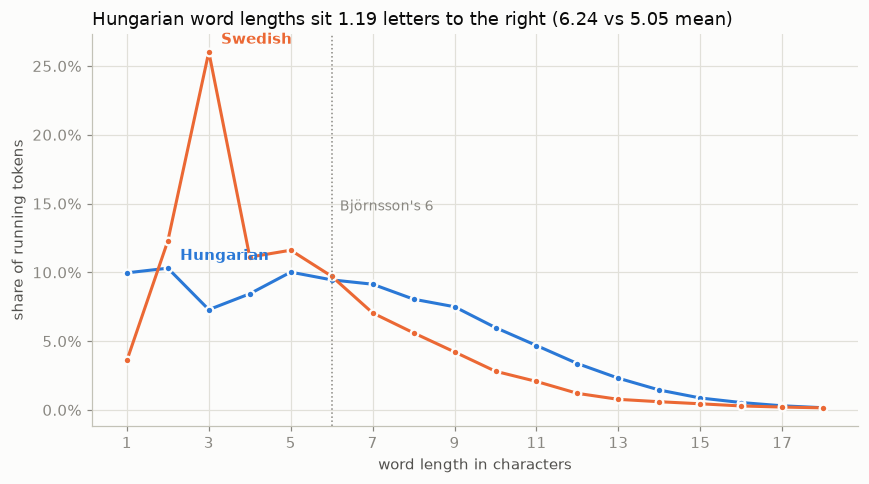

mokk-4pct      mean length 6.240  (554,861,558 tokens, 1,422,686 types)
leipzig-swe    mean length 5.052  (14,284,223 tokens, 89,887 types)


In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for label, colour, name in [
    ("mokk-4pct", HU, "Hungarian"),
    ("leipzig-swe", SV, "Swedish"),
]:
    ts, ss = shares(label, upto=18)
    # share(len == t) = share(> t-1) - share(> t)
    table = CURVES[label]["shares"]
    pmf = [table[str(t - 1)] - table[str(t)] for t in ts]
    ax.plot(ts, pmf, color=colour, marker="o", ms=5, label=name,
            markeredgecolor=SURFACE, markeredgewidth=1.5)
    peak = max(range(len(pmf)), key=lambda i: pmf[i])
    ax.annotate(name, xy=(ts[peak], pmf[peak]), xytext=(ts[peak] + 0.3, pmf[peak] + 0.006),
                color=colour, fontsize=10, fontweight="bold")

ax.axvline(6, color=MUTED, linewidth=1, linestyle=":")
ax.annotate("Björnsson's 6", xy=(6, 0), xytext=(6.2, 0.145), color=MUTED, fontsize=9)

hu_mean = CURVES["mokk-4pct"]["mean_length"]
sv_mean = CURVES["leipzig-swe"]["mean_length"]
ax.set_xlabel("word length in characters")
ax.set_ylabel("share of running tokens")
ax.set_title(
    f"Hungarian word lengths sit {hu_mean - sv_mean:.2f} letters to the right "
    f"({hu_mean:.2f} vs {sv_mean:.2f} mean)",
    loc="left", fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xticks(range(1, 19, 2))
plt.tight_layout()
plt.show()

for label in ("mokk-4pct", "leipzig-swe"):
    c = CURVES[label]
    print(f"{label:<14} mean length {c['mean_length']:.3f}  "
          f"({c['tokens']:,} tokens, {c['types']:,} types)")

## 3. Sensitivity — does the answer survive the methodology choices?Every curve below is Hungarian, so they share a hue. Each varies one decision:- **stratum** — the 4% sample is the principled choice (fewer errors than an average print  document); the 8% and full columns are progressively noisier.- **asterisk dropped** — what happens if the capitalisation marker is treated as part of the  word and those rows discarded. This is the single highest-consequence line in the reader.- **digraphs collapsed** — counting Hungarian *letters* rather than characters.

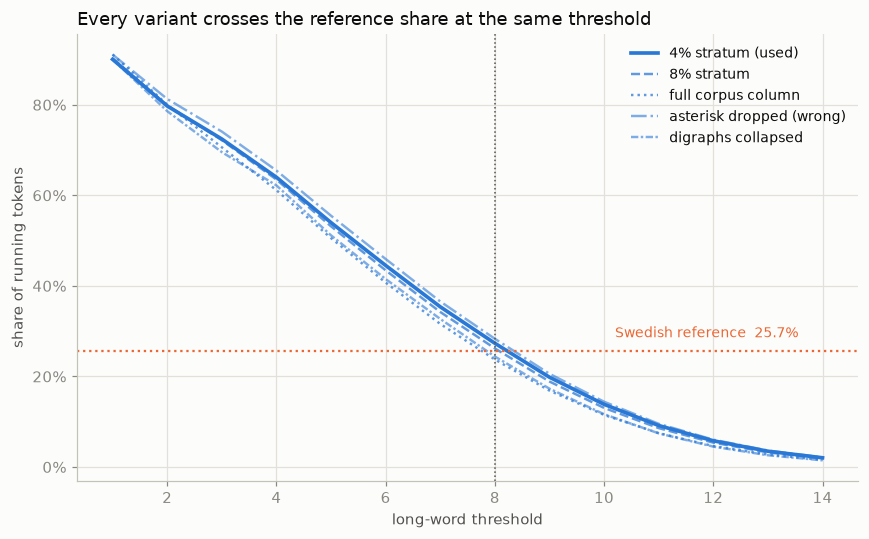

Threshold each curve would choose, matched independently:
  leipzig-hun                      → 8
  mokk-4pct                        → 8
  mokk-4pct-asterisk-dropped       → 8
  mokk-4pct-digraphs-collapsed     → 8
  mokk-8pct                        → 8
  mokk-full                        → 8

contested? False  (runner-up 9 misses by 0.0582 against the winner's 0.0168)


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

variants = [
    ("mokk-4pct", "-", 1.0, 2.4, "4% stratum (used)"),
    ("mokk-8pct", "--", 0.75, 1.6, "8% stratum"),
    ("mokk-full", ":", 0.75, 1.6, "full corpus column"),
    ("mokk-4pct-asterisk-dropped", "-.", 0.6, 1.6, "asterisk dropped (wrong)"),
    ("mokk-4pct-digraphs-collapsed", (0, (3, 1, 1, 1)), 0.6, 1.6, "digraphs collapsed"),
]
for label, style, alpha, lw, name in variants:
    ts, ss = shares(label)
    ax.plot(ts, ss, color=HU, linestyle=style, alpha=alpha, linewidth=lw, label=name)

ax.axhline(REC["reference_share"], color=SV, linewidth=1.5, linestyle=":")
ax.annotate(f"Swedish reference  {REC['reference_share']:.1%}",
            xy=(11, REC["reference_share"]), xytext=(10.2, REC["reference_share"] + 0.03),
            color=SV, fontsize=9)
ax.axvline(REC["long_word_threshold"], color=INK_2, linewidth=1, linestyle=":")

ax.set_xlabel("long-word threshold")
ax.set_ylabel("share of running tokens")
ax.set_title("Every variant crosses the reference share at the same threshold",
             loc="left", fontsize=12)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xticks(range(2, 15, 2))
ax.legend(frameon=False, fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

print("Threshold each curve would choose, matched independently:")
for source, threshold in REC["agreement"].items():
    print(f"  {source:<32} → {threshold}")
print(f"\ncontested? {REC['is_boundary']}  "
      f"(runner-up {REC['runner_up']} misses by {REC['runner_up_residual']:.4f} "
      f"against the winner's {REC['residual']:.4f})")

Unanimous. Worth noting what this looked like on a *truncated* sample: running the samepipeline against the 100k-most-frequent words — about 95% of tokens — the 8% and full-corpuscolumns picked **7** instead, and the choice really was near-arbitrary. The missing 5% isthe long tail, and including it pushed the Hungarian shares up. A single integer would havehidden that; the bracket and the agreement record do not.

## 4. What it does to an actual scoreThe frequency lists cannot supply *B*, the sentence count — so they can choose a thresholdbut cannot show what it does to a LIX score. A Webcorpus crawl part can: it is segmentedinto sentences as well as words, so *A*, *B* and *C* all come from the corpus.

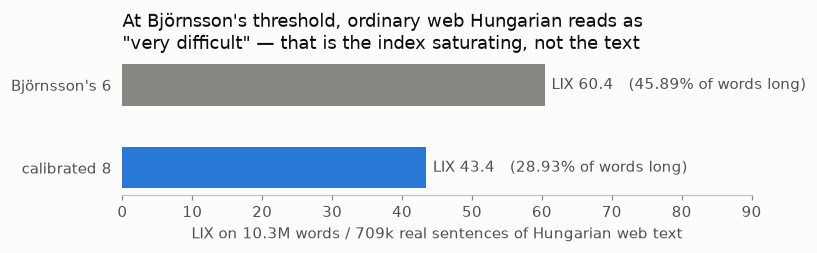

In [6]:
validation = (BASE / "validation.md").read_text()

# Pull the two scores straight out of the generated table, so this cell cannot
# drift from the artifact it is describing.
rows = [ln for ln in validation.splitlines() if ln.startswith("| Björnsson")
        or ln.startswith("| calibrated")]
scores = {}
for row in rows:
    cells_ = [c.strip() for c in row.strip("|").split("|")]
    scores[cells_[0]] = (cells_[2], float(cells_[3]))

fig, ax = plt.subplots(figsize=(7.5, 2.4))
labels = list(scores)
values = [v[1] for v in scores.values()]
colours = [MUTED, HU]
bars = ax.barh(labels, values, color=colours, height=0.5)
for bar, (share, score) in zip(bars, scores.values()):
    ax.annotate(f"LIX {score:.1f}   ({share} of words long)",
                xy=(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2),
                va="center", color=INK_2, fontsize=10)

ax.set_xlim(0, 90)
ax.invert_yaxis()  # Björnsson's row first, since that is the "before"
ax.grid(False)
ax.spines["left"].set_visible(False)
ax.tick_params(left=False, labelcolor=INK_2)
ax.set_xlabel("LIX on 10.3M words / 709k real sentences of Hungarian web text")
ax.set_title("At Björnsson's threshold, ordinary web Hungarian reads as\n"
             "\"very difficult\" — that is the index saturating, not the text",
             loc="left", fontsize=12)
plt.tight_layout()
plt.show()

## 5. The findings, as written`findings.md` and `validation.md` are generated by the scripts and committed alongside theJSON. They are the citable record; this notebook is the picture.

In [7]:
from IPython.display import Markdown, display

display(Markdown((BASE / "findings.md").read_text()))

# Findings: LIX threshold calibration for Hungarian
Generated: 2026-07-29T17:08:25+00:00  
Primary source: web2.2-freq-sorted.txt.gz  
saphes version: 0.1.0

---

## 1. Headline result

**Recommended Hungarian `long_word_threshold`: 8**  
Bracket: (8, 9)  
Matched share: 27.33% against a Swedish reference of 25.65% at threshold 6  
Residual: 0.0168

Björnsson's threshold of 6 selects 25.65% of running Swedish tokens. In Hungarian the same threshold selects 44.52% — the index saturates, and differences between texts stop showing up. Threshold 8 restores what the term means: the longest quarter or so of running words.

The nearest alternative, threshold 9, misses by 0.0582 against the winner's 0.0168 — a factor of 3.5. The choice is not on a knife edge.

---

## 2. Cumulative long-word shares

Token-weighted share of running words strictly longer than each threshold.

| curve | >4 | >5 | >6 | >7 | >8 | >9 | >10 | >11 | >12 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| `mokk-4pct` | 64.00% | 53.98% | 44.52% | 35.38% | 27.33% | 19.83% | 13.85% | 9.16% | 5.79% |
| `mokk-8pct` | 63.49% | 53.16% | 43.44% | 34.24% | 26.20% | 18.88% | 13.05% | 8.59% | 5.39% |
| `mokk-full` | 61.14% | 50.55% | 40.74% | 31.60% | 23.75% | 16.87% | 11.50% | 7.49% | 4.63% |
| `leipzig-hun` | 62.24% | 51.87% | 41.68% | 31.92% | 23.43% | 16.34% | 10.84% | 6.81% | 4.02% |
| `leipzig-swe` | 46.98% | 35.37% | 25.65% | 18.60% | 13.00% | 8.78% | 5.97% | 3.90% | 2.70% |
| `mokk-4pct-asterisk-dropped` | 65.48% | 55.50% | 45.94% | 36.57% | 28.33% | 20.60% | 14.42% | 9.55% | 6.04% |
| `mokk-4pct-digraphs-collapsed` | 62.19% | 51.16% | 41.51% | 32.71% | 24.40% | 17.30% | 11.66% | 7.44% | 4.51% |

| curve | tokens | types | mean length |
|---|---:|---:|---:|
| `mokk-4pct` | 554,861,558 | 1,422,686 | 6.240 |
| `mokk-8pct` | 870,983,275 | 2,007,713 | 6.161 |
| `mokk-full` | 1,360,685,516 | 3,023,270 | 5.963 |
| `leipzig-hun` | 15,786,586 | 151,296 | 5.937 |
| `leipzig-swe` | 14,284,223 | 89,887 | 5.052 |
| `mokk-4pct-asterisk-dropped` | 517,267,619 | 1,392,317 | 6.372 |
| `mokk-4pct-digraphs-collapsed` | 554,861,558 | 1,422,686 | 5.967 |

---

## 3. Which threshold each source would choose

Every curve matched independently against the same Swedish reference.

| curve | threshold |
|---|---:|
| `leipzig-hun` | 8 |
| `mokk-4pct` | 8 |
| `mokk-4pct-asterisk-dropped` | 8 |
| `mokk-4pct-digraphs-collapsed` | 8 |
| `mokk-8pct` | 8 |
| `mokk-full` | 8 |

---

## 4. Sensitivity

**Stratum.** `mokk-4pct` is the principled choice — the 4% stratum has fewer mistakes than an average print document, while the full-corpus column carries the crawl's junk. The 8% and full columns are shown so the cost of that choice is visible rather than assumed.

**Capitalisation marker.** `mokk-4pct-asterisk-dropped` shows what happens if the trailing `*` on sentence-initial forms is treated as part of the word and those rows discarded. They are overwhelmingly short function words, so dropping them biases the mean length upward and picks too high a threshold. This is the single highest-consequence line in the reader.

**Digraphs.** Hungarian `cs, dz, gy, ly, ny, sz, ty, zs, dzs` are single letters, so a character count is not a letter count. `mokk-4pct-digraphs-collapsed` recomputes on letters. It is a sensitivity check, not better ground truth: collapsing mis-fires at morpheme boundaries, where `község` is `köz` + `ség` and its `zs` is not the digraph. Character counting stays the default, as in Björnsson's original.

**Independent corpus.** `leipzig-hun` is a different corpus entirely — 2022 news rather than a 2003 web crawl, built by a different project with a different pipeline. That it lands close to `mokk-4pct` is the strongest evidence here that the saturation is a property of Hungarian rather than an artifact of the Webcorpus.

---

## 5. Caveats

- The MOKK Webcorpus crawl is from winter 2003: 2000s web Hungarian, not song lyrics, not literary prose. A general-language reference, not a register match.
- Register matters for readability. Before trusting this threshold on your own texts, recompute the long-word share on a sample of them and check it lands where the calibration predicts.
- A calibrated threshold is a default, not a truth. The parameter stays exposed precisely because no single number is right everywhere.

---

## 6. Sources and citations

**hu_primary** — `mokk-web2.2-4pct` (`web2.2-freq-sorted.txt.gz`)
  - 120,512,445 bytes, sha256 `3221f4a8a682a044…`
  - Halácsy, Kornai, Németh, Rung, Szakadát, Trón (2004). Creating open language resources for Hungarian. LREC.
  - Kornai, Halácsy, Nagy, Oravecz, Trón, Varga (2006). Web-based frequency dictionaries for medium density languages. Web as Corpus, ACL.

**sv_reference** — `leipzig-swe_news_2022_1M` (`swe_news_2022_1M.tar.gz`)
  - 191,328,913 bytes, sha256 `a39c02c421590a21…`
  - Goldhahn, Eckart, Quasthoff (2012). Building large monolingual dictionaries at the Leipzig Corpora Collection. LREC.

**hu_crosscheck** — `leipzig-hun_news_2022_1M` (`hun_news_2022_1M.tar.gz`)
  - 242,152,696 bytes, sha256 `60b78adfdb462353…`
  - Goldhahn, Eckart, Quasthoff (2012). Building large monolingual dictionaries at the Leipzig Corpora Collection. LREC.

---

## 7. Reproducing

```bash
uv run python experiments/lix_calibration/scripts/download_data.py
uv run python experiments/lix_calibration/scripts/run.py
```

The run asserts a set of regression anchors measured by hand before this script existed; if the reader ever starts producing different numbers it fails rather than quietly publishing them.


In [8]:
display(Markdown(validation))

# Validation: the calibrated threshold on running text

Generated by `scripts/validate_b.py`.

The frequency lists that produced the calibration cannot supply *B*, the
sentence count — so they can choose a threshold but cannot show what it does
to an actual LIX score. A Webcorpus crawl part can: it is segmented into
sentences as well as words, so *A*, *B* and *C* all come from the corpus.

## Sample

- Source: `web2-4p-0.tar.gz`, 20,000 documents read (limit 20000)
- Used 16,924; skipped 3,076 under 25 words
- **A = 10,275,343** words, **B = 709,274** sentences
- Mean sentence length: 14.49 words

## LIX, with real sentence counts

| threshold | C | long-word share | LIX |
|---|---:|---:|---:|
| Björnsson's 6 | 4,715,799 | 45.89% | 60.38 |
| calibrated 8 | 2,972,338 | 28.93% | 43.41 |

At Björnsson's threshold, ordinary 2000s web Hungarian scores 60.4 — deep in "very difficult", which is not a description of this text, it is the index saturating. At the calibrated threshold it scores 43.4.

## Does the calibration transfer?

The calibration predicted a long-word share of 27.33% for Hungarian at threshold 8. This running text gives 28.93% — a difference of 1.59 points.

That is a genuine check rather than a restatement: the calibration was built from the 4% stratum of a *frequency list*, and this is *running text* from crawl part 0. They are different views of the same corpus.

## The two contracts, on real Hungarian

Only 0.71% of tokens carry a morphological analysis, and they are not a random sample — the analyser emits one where it has something to say. So both streams are compared **over exactly those 73,042 tokens**, not lemma-subset against full-surface, which would compare two different samples and prove nothing.

| stream | TTR | mean word length |
|---|---:|---:|
| surface | 0.4060 | 6.75 |
| lemma | 0.3742 | 6.48 |

TTR gap **+0.0319**, word-length gap **+0.27**. Both point the way the package says they must: lemmatising removes morphology (so diversity needs lemmas) and removes length (so readability needs surface forms).

The gap is smaller here than on the bundled toy samples, and that is worth stating rather than hiding: the analysed subset is skewed toward the tokens the analyser flagged — foreign words, hyphenated forms, oddities — which are less richly inflected than ordinary Hungarian nouns.

## Reproducing

```bash
uv run python experiments/lix_calibration/scripts/download_data.py --with-corpus-part
uv run python experiments/lix_calibration/scripts/validate_b.py
```


## CaveatsRead these before using the number.

In [9]:
for caveat in record["caveats"]:
    print(f"- {caveat}\n")

- The MOKK Webcorpus crawl is from winter 2003: 2000s web Hungarian, not song lyrics, not literary prose. A general-language reference, not a register match.

- Register matters for readability. Before trusting this threshold on your own texts, recompute the long-word share on a sample of them and check it lands where the calibration predicts.

- A calibrated threshold is a default, not a truth. The parameter stays exposed precisely because no single number is right everywhere.



## Sources- Halácsy, Kornai, Németh, Rung, Szakadát, Trón (2004). *Creating open language resources  for Hungarian.* LREC.- Kornai, Halácsy, Nagy, Oravecz, Trón, Varga (2006). *Web-based frequency dictionaries for  medium density languages.* Web as Corpus, ACL.- Goldhahn, Eckart, Quasthoff (2012). *Building large monolingual dictionaries at the  Leipzig Corpora Collection.* LREC.The identical method transfers to Ancient Greek for the Homer project — different corpus,same procedure.